# R3 Algorithm — Data Loading

Load Round 3 price and trade data into pandas DataFrames.

In [72]:
import pandas as pd
from pathlib import Path

DATA_DIR = Path("../prosperity4bt/resources/round3")
DAYS = [0, 1, 2]

prices = pd.concat(
    [pd.read_csv(DATA_DIR / f"prices_round_3_day_{d}.csv", sep=";") for d in DAYS],
    ignore_index=True,
)
trades = pd.concat(
    [pd.read_csv(DATA_DIR / f"trades_round_3_day_{d}.csv", sep=";").assign(day=d) for d in DAYS],
    ignore_index=True,
)

print(f"prices: {len(prices):,} rows, {prices['product'].nunique()} products, days {sorted(prices['day'].unique())}")
print(f"trades: {len(trades):,} rows")

prices: 360,000 rows, 12 products, days [np.int64(0), np.int64(1), np.int64(2)]
trades: 4,048 rows


In [73]:
prices

,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss
0,0,0,VEV_5400,22,25,NaN,NaN,NaN,NaN,24,25,NaN,NaN,NaN,NaN,23.0,0.0
1,0,0,VEV_6500,0,16,NaN,NaN,NaN,NaN,1,16,NaN,NaN,NaN,NaN,0.5,0.0
2,0,0,VEV_5500,8,25,NaN,NaN,NaN,NaN,9,25,NaN,NaN,NaN,NaN,8.5,0.0
3,0,0,VEV_5200,100,19,NaN,NaN,NaN,NaN,103,6,104.0,13.0,NaN,NaN,101.5,0.0
4,0,0,VEV_5300,52,6,51.0,19.0,NaN,NaN,54,25,NaN,NaN,NaN,NaN,53.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
359995,2,999900,VELVETFRUIT_EXTRACT,5293,25,5292.0,39.0,NaN,NaN,5298,64,NaN,NaN,NaN,NaN,5295.5,0.0
359996,2,999900,VEV_4500,787,10,785.0,17.0,NaN,NaN,804,10,806.0,17.0,NaN,NaN,795.5,0.0
359997,2,999900,VEV_5400,19,28,NaN,NaN,NaN,NaN,21,28,NaN,NaN,NaN,NaN,20.0,0.0
359998,2,999900,VEV_6500,0,11,NaN,NaN,NaN,NaN,1,11,NaN,NaN,NaN,NaN,0.5,0.0


In [74]:
trades

,timestamp,buyer,seller,symbol,currency,price,quantity,day
0,2500,NaN,NaN,VELVETFRUIT_EXTRACT,XIRECS,5250.0,4,0
1,2900,NaN,NaN,VEV_5400,XIRECS,22.0,3,0
2,2900,NaN,NaN,VEV_5500,XIRECS,8.0,3,0
3,2900,NaN,NaN,VEV_6000,XIRECS,0.0,3,0
4,2900,NaN,NaN,VEV_6500,XIRECS,0.0,3,0
...,...,...,...,...,...,...,...,...
4043,995100,NaN,NaN,VELVETFRUIT_EXTRACT,XIRECS,5289.0,7,2
4044,996300,NaN,NaN,VELVETFRUIT_EXTRACT,XIRECS,5290.0,3,2
4045,996500,NaN,NaN,HYDROGEL_PACK,XIRECS,10010.0,2,2
4046,996500,NaN,NaN,VELVETFRUIT_EXTRACT,XIRECS,5291.0,3,2


In [75]:
prices[prices['product'] == 'VELVETFRUIT_EXTRACT'].head()  # 5 consecutive ticks for one product
prices.pivot_table(index=['day','timestamp'], columns='product', values='mid_price').head()  # wide format

product        HYDROGEL_PACK  VELVETFRUIT_EXTRACT  VEV_4000  VEV_4500  \
day timestamp                                                           
0   0                10000.0               5250.0    1250.0     750.0   
    100              10000.0               5250.5    1250.5     751.0   
    200              10003.0               5250.5    1250.5     750.0   
    300              10002.0               5250.5    1250.5     750.0   
    400              10003.0               5250.5    1250.5     750.0   

product        VEV_5000  VEV_5100  VEV_5200  VEV_5300  VEV_5400  VEV_5500  \
day timestamp                                                               
0   0             257.0     171.5     101.5      53.0      23.0       8.5   
    100           258.0     172.0     102.5      53.0      23.5       8.5   
    200           257.0     172.0     102.5      53.0      23.5       8.5   
    300           257.5     172.0     102.5      53.0      23.5       8.5   
    400           257.0     172.0     102.5      53.0      23.5       8.5   

product        VEV_6000  VEV_6500  
day timestamp                      
0   0               0.5       0.5  
    100             0.5       0.5  
    200             0.5       0.5  
    300             0.5       0.5  
    400             0.5       0.5

## Vol analytics

Three plots, ATM-centred strikes only (`VEV_5000`–`VEV_5500`). One global parabolic smile fit over all `(m, iv)` points; per-row fitted IV uses each tick's own moneyness. Setup cell is slow (~15 s, ~60 k IV solves).

1. **Vol smile** — scatter of every tick × strike, parabola overlay.
2. **IV deviations over time** — actual IV − fitted IV, per strike.
3. **Price deviations over time** — actual mid − BS theoretical (theoretical uses fitted IV).

In [76]:
import sys; sys.path.append('..')
from utils.options_toolkit import implied_vol, bs_price
import numpy as np
import matplotlib.pyplot as plt

STRIKES = {p: int(p.split('_')[1]) for p in prices['product'].unique() if p.startswith('VEV_')}
TTE = {0: 7/365, 1: 6/365, 2: 5/365}
USABLE = ['VEV_5000', 'VEV_5100', 'VEV_5200',
          'VEV_5300', 'VEV_5400', 'VEV_5500']  # skip 4000/4500 (deep ITM) and 6000/6500 (floor-pinned)

spot_df = (prices[prices['product'] == 'VELVETFRUIT_EXTRACT']
           [['day','timestamp','mid_price']].rename(columns={'mid_price':'spot'}))

voucher = (prices[prices['product'].isin(USABLE)]
           .merge(spot_df, on=['day','timestamp'])
           .assign(K=lambda d: d['product'].map(STRIKES),
                   T=lambda d: d['day'].map(TTE)))

# Time-scaled log-moneyness (Frankfurt Hedgehogs convention): m = ln(K/S) / √T
voucher['m'] = np.log(voucher['K'] / voucher['spot']) / np.sqrt(voucher['T'])
voucher['intrinsic'] = np.maximum(0, voucher['spot'] - voucher['K'])
voucher['extrinsic'] = voucher['mid_price'] - voucher['intrinsic']

def safe_iv(m, s, k, t):
    try: return implied_vol(m, s, k, t, 0.0)
    except Exception: return float('nan')

voucher['iv'] = [safe_iv(m, s, k, t) for m, s, k, t in
                 zip(voucher['mid_price'], voucher['spot'], voucher['K'], voucher['T'])]

# Clean: drop NaN IV, require positive extrinsic (arbitrage filter), IV bounds
clean = voucher.dropna(subset=['iv'])
clean = clean[(clean['extrinsic'] > 0) & (clean['iv'] > 0.05) & (clean['iv'] < 2.0)]

# Global parabola fit on all clean (m, iv) points
a, b, c = np.polyfit(clean['m'].values, clean['iv'].values, 2)

# Per-row fitted IV (uses each row's own time-scaled m)
voucher['fitted_iv'] = a * voucher['m']**2 + b * voucher['m'] + c
voucher['iv_dev'] = voucher['iv'] - voucher['fitted_iv']

# Per-row BS theoretical price using fitted IV
voucher['theo_price'] = [
    bs_price(s, k, t, 0.0, fv) if fv > 0 else float('nan')
    for s, k, t, fv in zip(voucher['spot'], voucher['K'], voucher['T'], voucher['fitted_iv'])
]
voucher['price_dev'] = voucher['mid_price'] - voucher['theo_price']

print(f"Rows: {len(voucher):,}  | Clean fit points: {len(clean):,}")
print(f"Parabola: IV = {a:.4f}·m² + {b:.4f}·m + {c:.4f}")
print(f"m range: [{voucher['m'].min():.2f}, {voucher['m'].max():.2f}]")

Rows: 180,000  | Clean fit points: 179,976
Parabola: IV = 0.0320·m² + 0.0024·m + 0.2491
m range: [-0.50, 0.47]


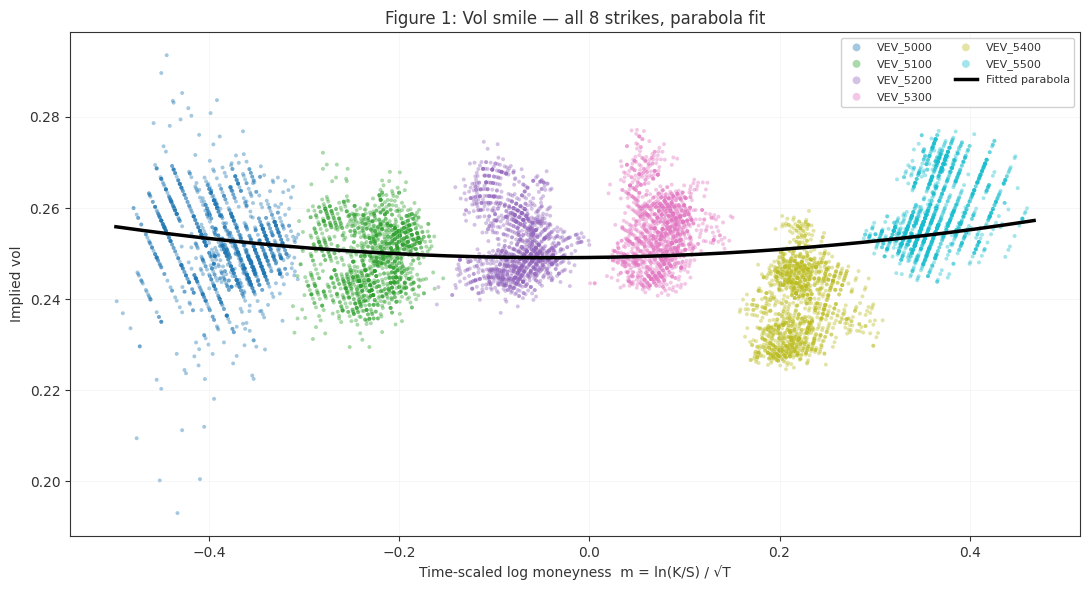

In [77]:
plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'axes.edgecolor': '#333', 'axes.labelcolor': '#333', 'axes.titlecolor': '#333',
    'xtick.color': '#333', 'ytick.color': '#333', 'text.color': '#333',
    'grid.color': '#ddd', 'legend.facecolor': 'white', 'legend.edgecolor': '#ccc',
})

SAMPLE = 20
sample = voucher[(voucher['extrinsic'] > 0) & voucher['iv'].between(0.05, 2.0)].iloc[::SAMPLE]

fig, ax = plt.subplots(figsize=(11, 6), facecolor='white')
palette = plt.cm.tab10(np.linspace(0, 1, len(USABLE)))
for color, sym in zip(palette, USABLE):
    sub = sample[sample['product'] == sym]
    ax.scatter(sub['m'], sub['iv'], s=8, alpha=0.4, color=color, label=sym, edgecolor='none')

m_curve = np.linspace(clean['m'].min(), clean['m'].max(), 200)
fit_curve = a*m_curve**2 + b*m_curve + c
ax.plot(m_curve, fit_curve, 'k-', linewidth=2.5, label='Fitted parabola')

ax.set_xlabel('Time-scaled log moneyness  m = ln(K/S) / √T')
ax.set_ylabel('Implied vol')
ax.set_title('Figure 1: Vol smile — all 8 strikes, parabola fit')
ax.legend(loc='upper right', markerscale=2, framealpha=0.9, ncol=2, fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

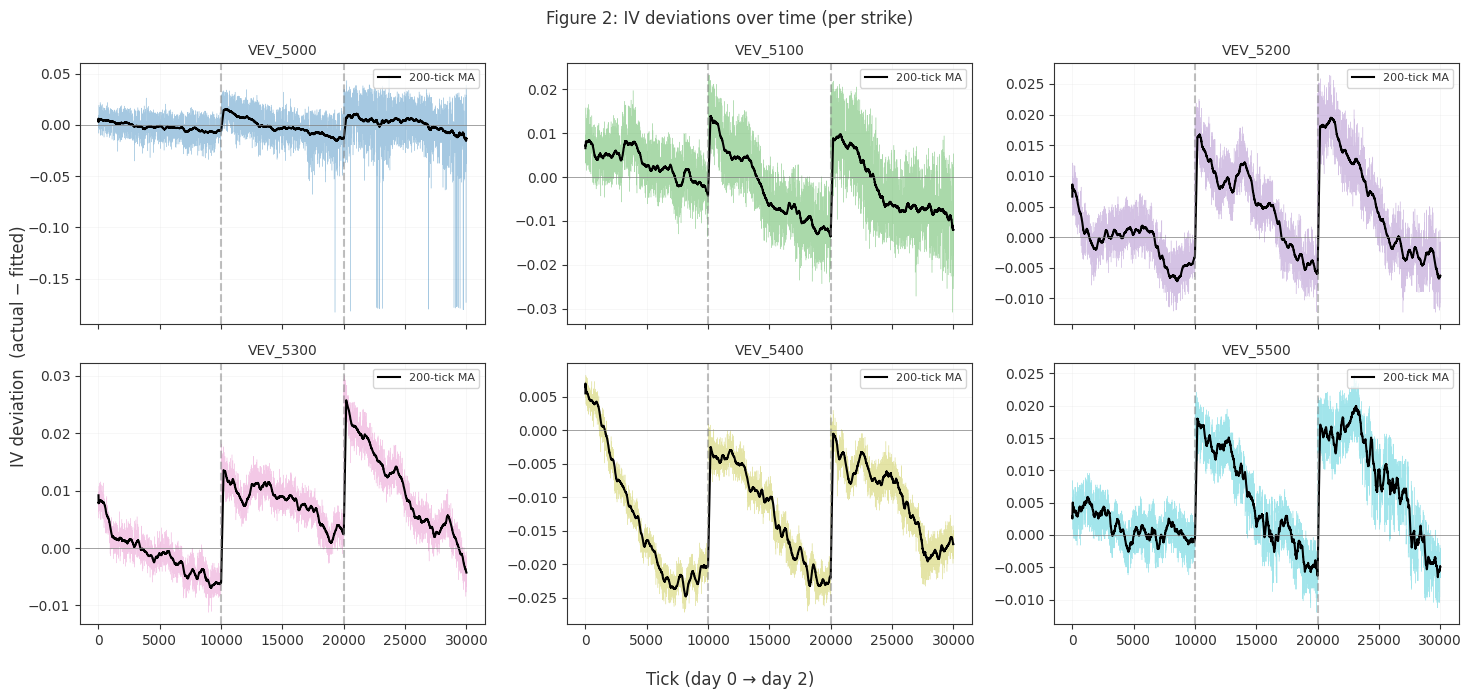

In [78]:
plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'axes.edgecolor': '#333', 'axes.labelcolor': '#333', 'axes.titlecolor': '#333',
    'xtick.color': '#333', 'ytick.color': '#333', 'text.color': '#333',
    'grid.color': '#ddd', 'legend.facecolor': 'white', 'legend.edgecolor': '#ccc',
})

fig, axes = plt.subplots(2, 3, figsize=(15, 7), sharex=True, facecolor='white')
palette = plt.cm.tab10(np.linspace(0, 1, len(USABLE)))

for ax, color, sym in zip(axes.flat, palette, USABLE):
    sub = voucher[voucher['product'] == sym].sort_values(['day','timestamp']).reset_index(drop=True)
    x = np.arange(len(sub))
    ax.plot(x, sub['iv_dev'], linewidth=0.3, alpha=0.4, color=color)
    ax.plot(x, sub['iv_dev'].rolling(200, min_periods=1).mean(),
            linewidth=1.5, color='black', label='200-tick MA')
    ax.axhline(y=0, color='gray', linewidth=0.5)
    for d in [1, 2]:
        ax.axvline(x=10000*d, color='gray', linestyle='--', alpha=0.5)
    ax.set_title(sym, fontsize=10)
    ax.legend(fontsize=8, loc='upper right')
    ax.grid(alpha=0.3)

fig.suptitle('Figure 2: IV deviations over time (per strike)', fontsize=12)
fig.supxlabel('Tick (day 0 → day 2)')
fig.supylabel('IV deviation  (actual − fitted)')
plt.tight_layout()
plt.show()

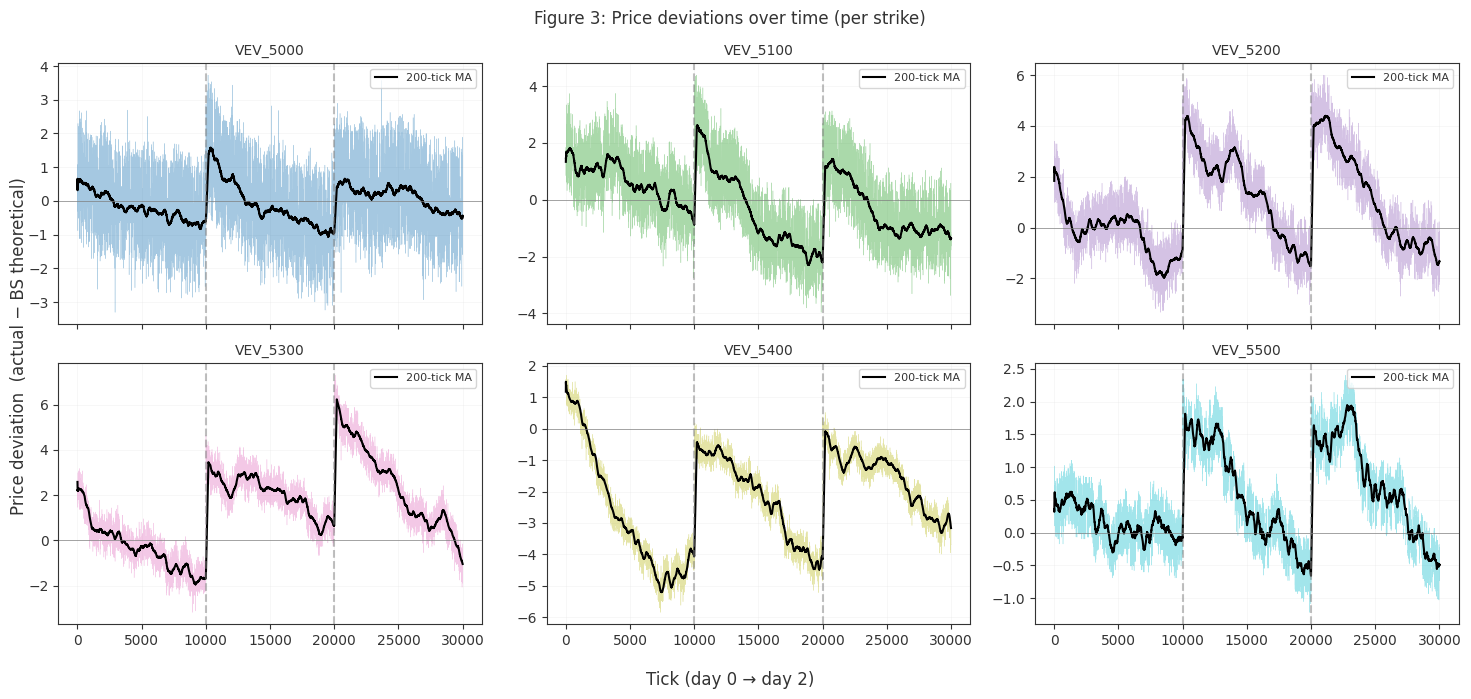

In [79]:
plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'axes.edgecolor': '#333', 'axes.labelcolor': '#333', 'axes.titlecolor': '#333',
    'xtick.color': '#333', 'ytick.color': '#333', 'text.color': '#333',
    'grid.color': '#ddd', 'legend.facecolor': 'white', 'legend.edgecolor': '#ccc',
})

fig, axes = plt.subplots(2, 3, figsize=(15, 7), sharex=True, facecolor='white')
palette = plt.cm.tab10(np.linspace(0, 1, len(USABLE)))

for ax, color, sym in zip(axes.flat, palette, USABLE):
    sub = voucher[voucher['product'] == sym].sort_values(['day','timestamp']).reset_index(drop=True)
    x = np.arange(len(sub))
    ax.plot(x, sub['price_dev'], linewidth=0.3, alpha=0.4, color=color)
    ax.plot(x, sub['price_dev'].rolling(200, min_periods=1).mean(),
            linewidth=1.5, color='black', label='200-tick MA')
    ax.axhline(y=0, color='gray', linewidth=0.5)
    for d in [1, 2]:
        ax.axvline(x=10000*d, color='gray', linestyle='--', alpha=0.5)
    ax.set_title(sym, fontsize=10)
    ax.legend(fontsize=8, loc='upper right')
    ax.grid(alpha=0.3)

fig.suptitle('Figure 3: Price deviations over time (per strike)', fontsize=12)
fig.supxlabel('Tick (day 0 → day 2)')
fig.supylabel('Price deviation  (actual − BS theoretical)')
plt.tight_layout()
plt.show()

## Per-day parabola fit

Fit a separate parabola `(a_d, b_d, c_d)` for each TTE day (0, 1, 2). Each day's fitted IV uses its own day's coefficients, removing the day-boundary jumps that a single global fit produced.

Adds new columns to `voucher`: `fitted_iv_daily`, `iv_dev_daily`, `theo_price_daily`, `price_dev_daily`. Existing columns (`fitted_iv`, `iv_dev`, `theo_price`, `price_dev`) from the global fit are untouched, so Figures 1–3 still work as before.

In [80]:
# Per-day parabola fits — one (a, b, c) per TTE day.
# Reuses voucher, USABLE, TTE, bs_price from the earlier setup cell.

fits_by_day = {}
for d in sorted(voucher['day'].unique()):
    clean_d = voucher[(voucher['day'] == d) & voucher['iv'].notna()
                      & (voucher['extrinsic'] > 0)
                      & voucher['iv'].between(0.05, 2.0)]
    a_d, b_d, c_d = np.polyfit(clean_d['m'].values, clean_d['iv'].values, 2)
    fits_by_day[d] = (a_d, b_d, c_d)
    print(f"Day {d}: IV = {a_d:+.4f}·m² {b_d:+.4f}·m {c_d:+.4f}  (n={len(clean_d):,})")

# Broadcast each row's day-specific coefficients
a_map = {d: f[0] for d, f in fits_by_day.items()}
b_map = {d: f[1] for d, f in fits_by_day.items()}
c_map = {d: f[2] for d, f in fits_by_day.items()}

voucher['fitted_iv_daily'] = (voucher['day'].map(a_map) * voucher['m']**2
                               + voucher['day'].map(b_map) * voucher['m']
                               + voucher['day'].map(c_map))
voucher['iv_dev_daily'] = voucher['iv'] - voucher['fitted_iv_daily']

voucher['theo_price_daily'] = [
    bs_price(s, k, t, 0.0, fv) if fv > 0 else float('nan')
    for s, k, t, fv in zip(voucher['spot'], voucher['K'], voucher['T'], voucher['fitted_iv_daily'])
]
voucher['price_dev_daily'] = voucher['mid_price'] - voucher['theo_price_daily']

Day 0: IV = +0.0434·m² -0.0039·m +0.2462  (n=60,000)
Day 1: IV = +0.0127·m² +0.0045·m +0.2506  (n=59,999)
Day 2: IV = +0.0306·m² +0.0053·m +0.2514  (n=59,977)


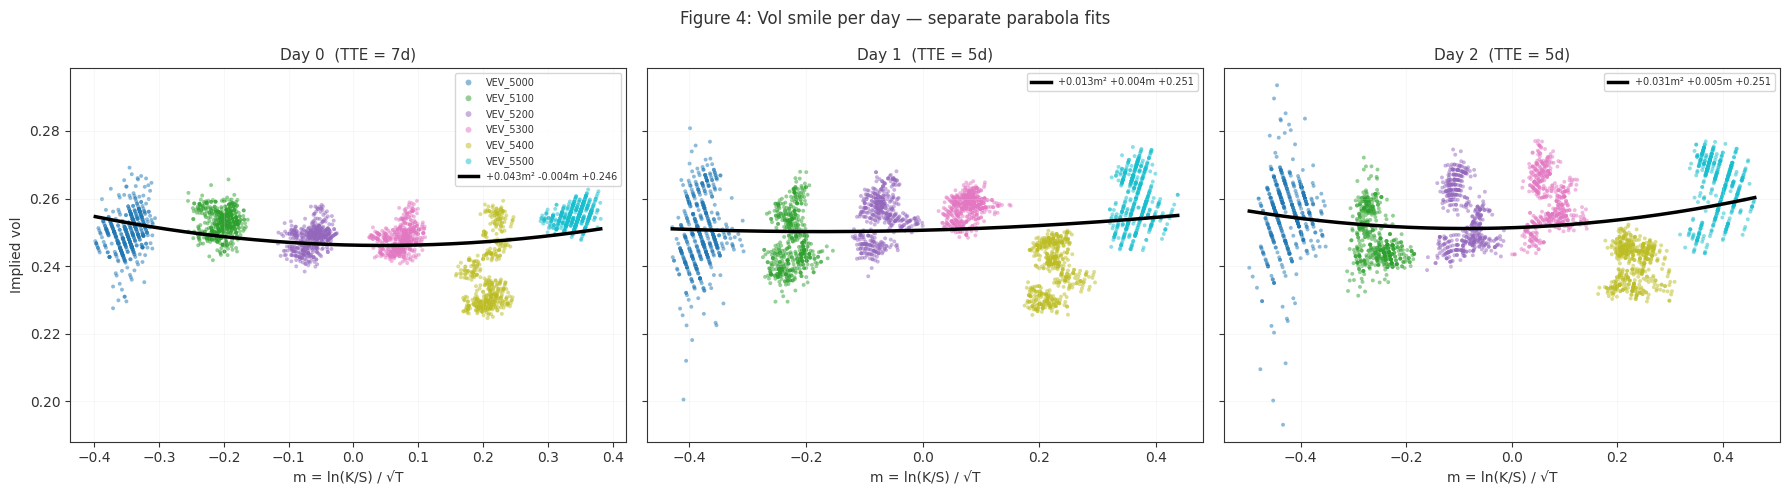

In [81]:
plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'axes.edgecolor': '#333', 'axes.labelcolor': '#333', 'axes.titlecolor': '#333',
    'xtick.color': '#333', 'ytick.color': '#333', 'text.color': '#333',
    'grid.color': '#ddd', 'legend.facecolor': 'white', 'legend.edgecolor': '#ccc',
})

SAMPLE = 20
sample = voucher[(voucher['extrinsic'] > 0) & voucher['iv'].between(0.05, 2.0)].iloc[::SAMPLE]

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True, facecolor='white')
palette = plt.cm.tab10(np.linspace(0, 1, len(USABLE)))

for ax, d in zip(axes, sorted(fits_by_day.keys())):
    day_sample = sample[sample['day'] == d]
    for color, sym in zip(palette, USABLE):
        sub = day_sample[day_sample['product'] == sym]
        ax.scatter(sub['m'], sub['iv'], s=8, alpha=0.5, color=color, edgecolor='none',
                   label=sym if d == sorted(fits_by_day.keys())[0] else None)
    a_d, b_d, c_d = fits_by_day[d]
    m_range = np.linspace(day_sample['m'].min(), day_sample['m'].max(), 200)
    fit = a_d * m_range**2 + b_d * m_range + c_d
    ax.plot(m_range, fit, 'k-', linewidth=2.5,
            label=f'{a_d:+.3f}m² {b_d:+.3f}m {c_d:+.3f}')
    tte_d = int(TTE[d] * 365)
    ax.set_title(f'Day {d}  (TTE = {tte_d}d)', fontsize=11)
    ax.set_xlabel('m = ln(K/S) / √T')
    ax.grid(alpha=0.3)
    ax.legend(fontsize=7, loc='upper right', markerscale=1.5)

axes[0].set_ylabel('Implied vol')
fig.suptitle('Figure 4: Vol smile per day — separate parabola fits', fontsize=12)
plt.tight_layout()
plt.show()

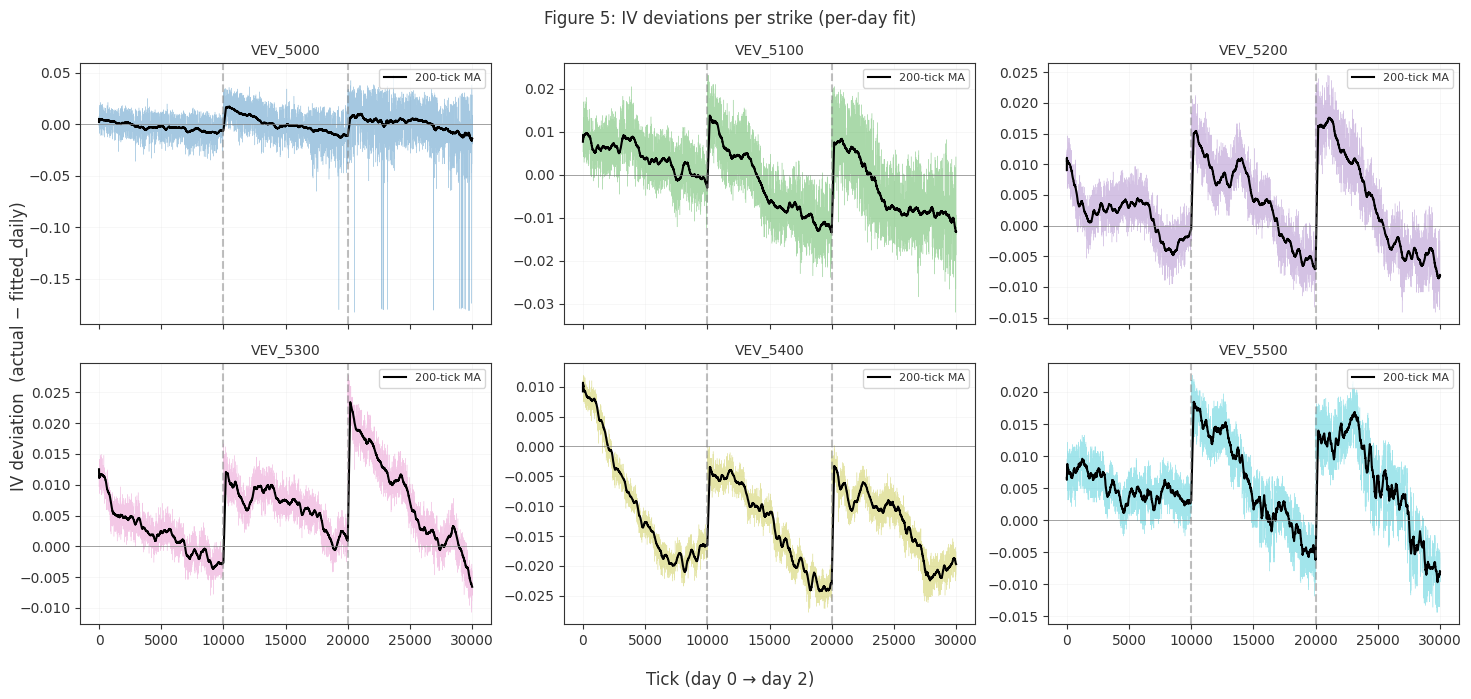

In [82]:
plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'axes.edgecolor': '#333', 'axes.labelcolor': '#333', 'axes.titlecolor': '#333',
    'xtick.color': '#333', 'ytick.color': '#333', 'text.color': '#333',
    'grid.color': '#ddd', 'legend.facecolor': 'white', 'legend.edgecolor': '#ccc',
})

fig, axes = plt.subplots(2, 3, figsize=(15, 7), sharex=True, facecolor='white')
palette = plt.cm.tab10(np.linspace(0, 1, len(USABLE)))

for ax, color, sym in zip(axes.flat, palette, USABLE):
    sub = voucher[voucher['product'] == sym].sort_values(['day','timestamp']).reset_index(drop=True)
    x = np.arange(len(sub))
    ax.plot(x, sub['iv_dev_daily'], linewidth=0.3, alpha=0.4, color=color)
    ax.plot(x, sub['iv_dev_daily'].rolling(200, min_periods=1).mean(),
            linewidth=1.5, color='black', label='200-tick MA')
    ax.axhline(y=0, color='gray', linewidth=0.5)
    for d in [1, 2]:
        ax.axvline(x=10000*d, color='gray', linestyle='--', alpha=0.5)
    ax.set_title(sym, fontsize=10)
    ax.legend(fontsize=8, loc='upper right')
    ax.grid(alpha=0.3)

fig.suptitle('Figure 5: IV deviations per strike (per-day fit)', fontsize=12)
fig.supxlabel('Tick (day 0 → day 2)')
fig.supylabel('IV deviation  (actual − fitted_daily)')
plt.tight_layout()
plt.show()

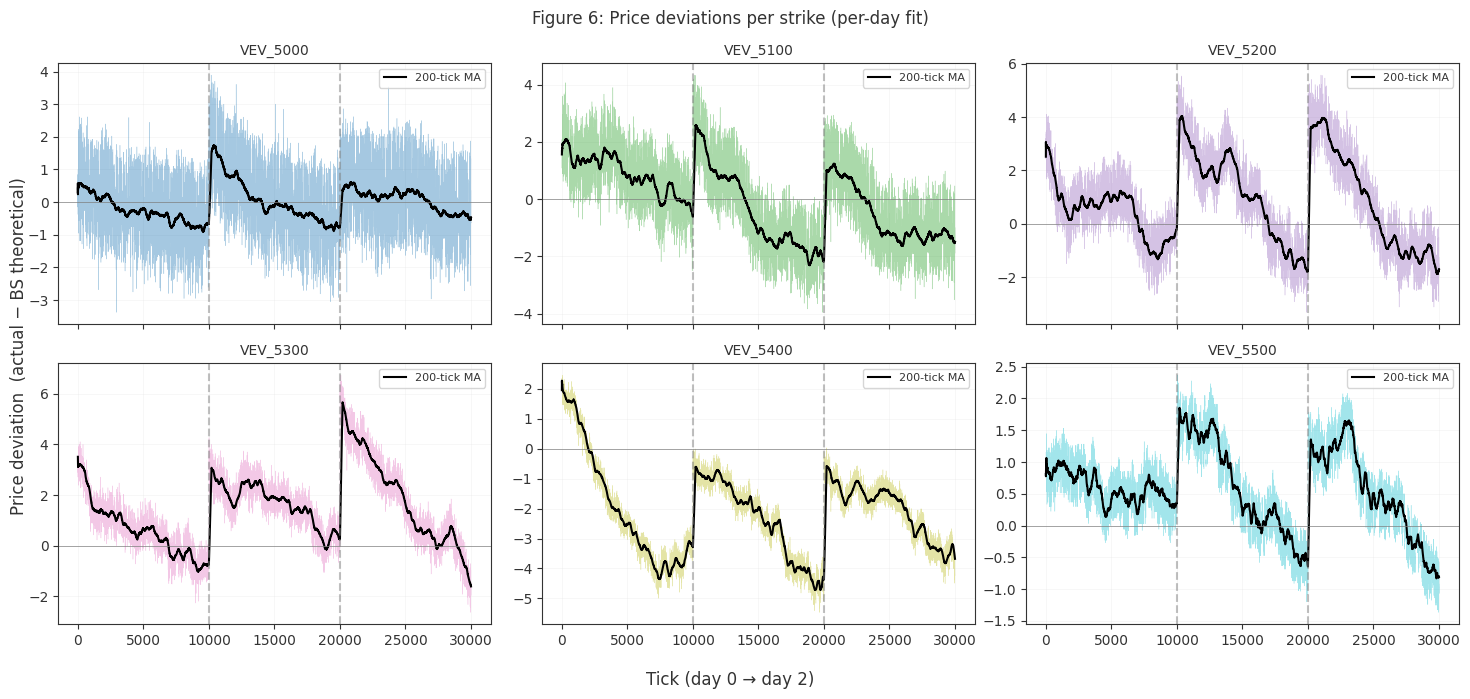

In [83]:
plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'axes.edgecolor': '#333', 'axes.labelcolor': '#333', 'axes.titlecolor': '#333',
    'xtick.color': '#333', 'ytick.color': '#333', 'text.color': '#333',
    'grid.color': '#ddd', 'legend.facecolor': 'white', 'legend.edgecolor': '#ccc',
})

fig, axes = plt.subplots(2, 3, figsize=(15, 7), sharex=True, facecolor='white')
palette = plt.cm.tab10(np.linspace(0, 1, len(USABLE)))

for ax, color, sym in zip(axes.flat, palette, USABLE):
    sub = voucher[voucher['product'] == sym].sort_values(['day','timestamp']).reset_index(drop=True)
    x = np.arange(len(sub))
    ax.plot(x, sub['price_dev_daily'], linewidth=0.3, alpha=0.4, color=color)
    ax.plot(x, sub['price_dev_daily'].rolling(200, min_periods=1).mean(),
            linewidth=1.5, color='black', label='200-tick MA')
    ax.axhline(y=0, color='gray', linewidth=0.5)
    for d in [1, 2]:
        ax.axvline(x=10000*d, color='gray', linestyle='--', alpha=0.5)
    ax.set_title(sym, fontsize=10)
    ax.legend(fontsize=8, loc='upper right')
    ax.grid(alpha=0.3)

fig.suptitle('Figure 6: Price deviations per strike (per-day fit)', fontsize=12)
fig.supxlabel('Tick (day 0 → day 2)')
fig.supylabel('Price deviation  (actual − BS theoretical)')
plt.tight_layout()
plt.show()

## Option A — Parabola (per-day) + strike fixed effects

On top of the per-day parabola fit, add a per-strike constant `δ_K` equal to the mean residual at that strike. The new fitted IV = `parabola_d(m) + δ_K`, absorbing the persistent bias seen in Figure 5. Adds columns `fitted_iv_A`, `iv_dev_A`, `theo_price_A`, `price_dev_A` to `voucher`.

In [84]:
# Option A: per-day parabola fit + per-strike fixed effects
# Strike bias = mean of daily-fit residuals per strike (the persistent per-strike offset)
strike_bias = voucher.groupby('product')['iv_dev_daily'].mean()

print("Per-strike bias δ_K (from per-day-fit residuals):")
for sym in USABLE:
    print(f"  {sym}: {strike_bias[sym]:+.4f}")

voucher['fitted_iv_A'] = voucher['fitted_iv_daily'] + voucher['product'].map(strike_bias)
voucher['iv_dev_A'] = voucher['iv'] - voucher['fitted_iv_A']

voucher['theo_price_A'] = [
    bs_price(s, k, t, 0.0, fv) if fv > 0 else float('nan')
    for s, k, t, fv in zip(voucher['spot'], voucher['K'], voucher['T'], voucher['fitted_iv_A'])
]
voucher['price_dev_A'] = voucher['mid_price'] - voucher['theo_price_A']

Per-strike bias δ_K (from per-day-fit residuals):
  VEV_5000: -0.0009
  VEV_5100: -0.0008
  VEV_5200: +0.0030
  VEV_5300: +0.0054
  VEV_5400: -0.0121
  VEV_5500: +0.0054


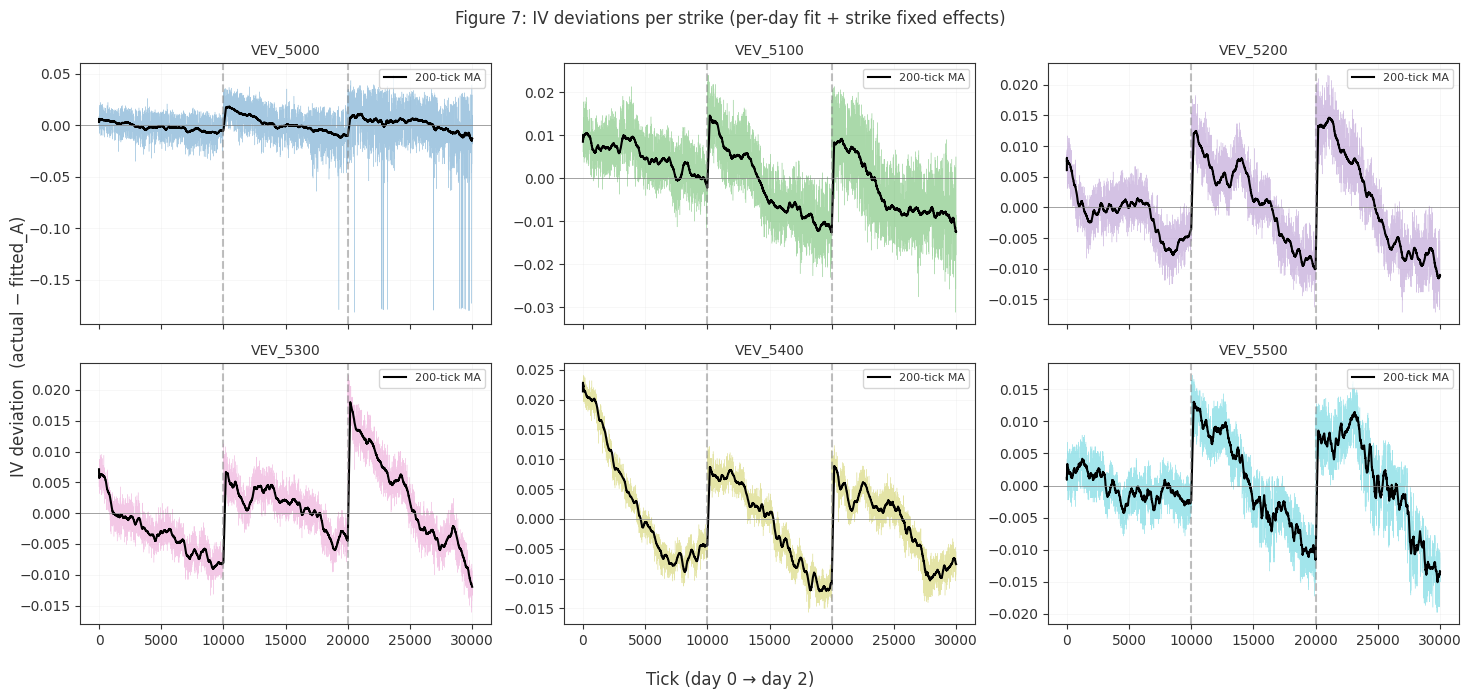

In [85]:
plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'axes.edgecolor': '#333', 'axes.labelcolor': '#333', 'axes.titlecolor': '#333',
    'xtick.color': '#333', 'ytick.color': '#333', 'text.color': '#333',
    'grid.color': '#ddd', 'legend.facecolor': 'white', 'legend.edgecolor': '#ccc',
})

fig, axes = plt.subplots(2, 3, figsize=(15, 7), sharex=True, facecolor='white')
palette = plt.cm.tab10(np.linspace(0, 1, len(USABLE)))

for ax, color, sym in zip(axes.flat, palette, USABLE):
    sub = voucher[voucher['product'] == sym].sort_values(['day','timestamp']).reset_index(drop=True)
    x = np.arange(len(sub))
    ax.plot(x, sub['iv_dev_A'], linewidth=0.3, alpha=0.4, color=color)
    ax.plot(x, sub['iv_dev_A'].rolling(200, min_periods=1).mean(),
            linewidth=1.5, color='black', label='200-tick MA')
    ax.axhline(y=0, color='gray', linewidth=0.5)
    for d in [1, 2]:
        ax.axvline(x=10000*d, color='gray', linestyle='--', alpha=0.5)
    ax.set_title(sym, fontsize=10)
    ax.legend(fontsize=8, loc='upper right')
    ax.grid(alpha=0.3)

fig.suptitle('Figure 7: IV deviations per strike (per-day fit + strike fixed effects)', fontsize=12)
fig.supxlabel('Tick (day 0 → day 2)')
fig.supylabel('IV deviation  (actual − fitted_A)')
plt.tight_layout()
plt.show()

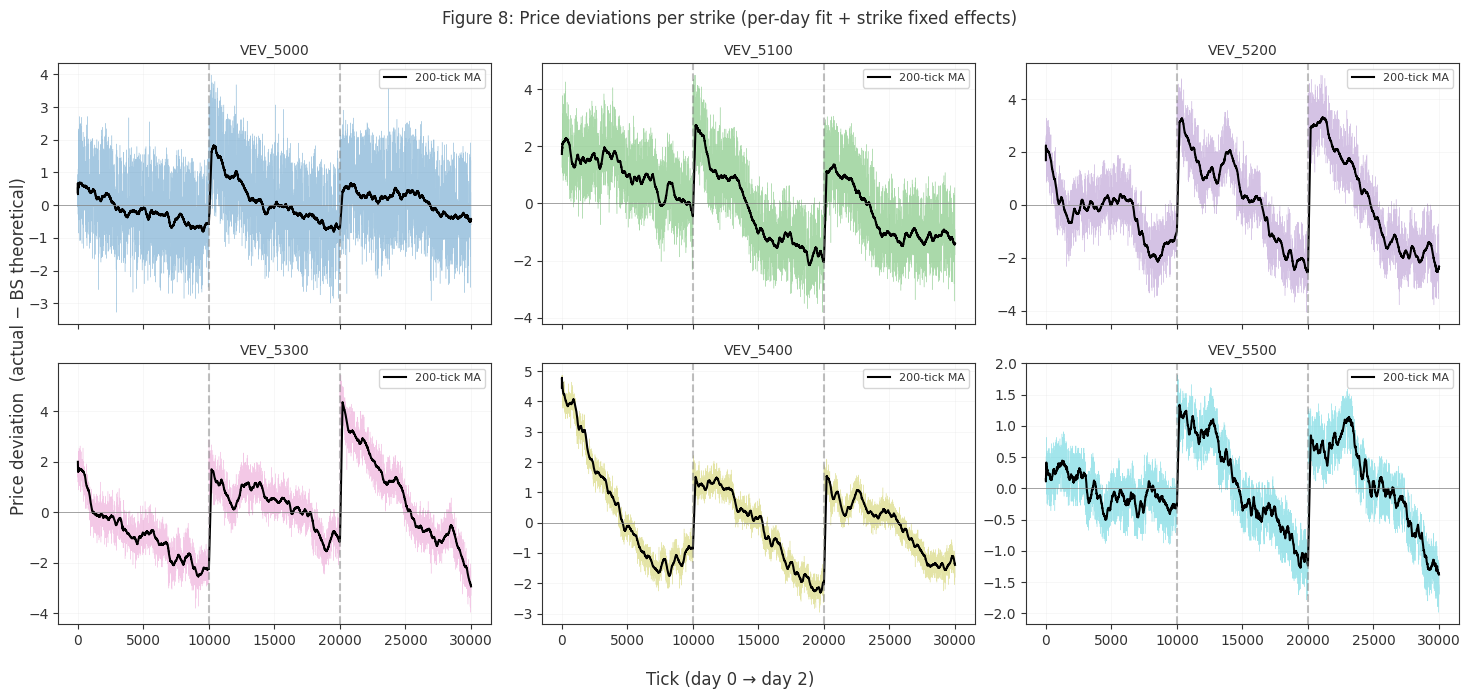

In [86]:
plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'axes.edgecolor': '#333', 'axes.labelcolor': '#333', 'axes.titlecolor': '#333',
    'xtick.color': '#333', 'ytick.color': '#333', 'text.color': '#333',
    'grid.color': '#ddd', 'legend.facecolor': 'white', 'legend.edgecolor': '#ccc',
})

fig, axes = plt.subplots(2, 3, figsize=(15, 7), sharex=True, facecolor='white')
palette = plt.cm.tab10(np.linspace(0, 1, len(USABLE)))

for ax, color, sym in zip(axes.flat, palette, USABLE):
    sub = voucher[voucher['product'] == sym].sort_values(['day','timestamp']).reset_index(drop=True)
    x = np.arange(len(sub))
    ax.plot(x, sub['price_dev_A'], linewidth=0.3, alpha=0.4, color=color)
    ax.plot(x, sub['price_dev_A'].rolling(200, min_periods=1).mean(),
            linewidth=1.5, color='black', label='200-tick MA')
    ax.axhline(y=0, color='gray', linewidth=0.5)
    for d in [1, 2]:
        ax.axvline(x=10000*d, color='gray', linestyle='--', alpha=0.5)
    ax.set_title(sym, fontsize=10)
    ax.legend(fontsize=8, loc='upper right')
    ax.grid(alpha=0.3)

fig.suptitle('Figure 8: Price deviations per strike (per-day fit + strike fixed effects)', fontsize=12)
fig.supxlabel('Tick (day 0 → day 2)')
fig.supylabel('Price deviation  (actual − BS theoretical)')
plt.tight_layout()
plt.show()

## Option C — Per-strike rolling z-score (no smile fit)

For each strike independently, compute `z = (iv − rolling_mean) / rolling_std` over a 500-tick trailing window. Bypasses smile modelling completely — each strike is its own timeseries. Signal: `|z| > 2` means the strike's IV is unusually high/low vs its own recent history (mean-reversion trade candidate).

In [87]:
# Option C: per-strike rolling z-score (skip smile modelling entirely)
WINDOW = 500

iv_wide = (voucher.sort_values(['day','timestamp'])
           .pivot_table(index=['day','timestamp'], columns='product', values='iv'))

mean_wide = iv_wide.rolling(WINDOW, min_periods=50).mean()
std_wide  = iv_wide.rolling(WINDOW, min_periods=50).std()
z_wide = (iv_wide - mean_wide) / std_wide

print(f"Window: {WINDOW} ticks. Per-strike summary:")
for sym in USABLE:
    z_vals = z_wide[sym].dropna()
    pct_extreme = (z_vals.abs() > 2).mean() * 100
    print(f"  {sym}: std={z_vals.std():.2f}  |z|>2 in {pct_extreme:.1f}% of ticks")

Window: 500 ticks. Per-strike summary:
  VEV_5000: std=1.04  |z|>2 in 6.9% of ticks
  VEV_5100: std=1.07  |z|>2 in 7.2% of ticks
  VEV_5200: std=1.13  |z|>2 in 7.1% of ticks
  VEV_5300: std=1.14  |z|>2 in 7.1% of ticks
  VEV_5400: std=1.17  |z|>2 in 8.6% of ticks
  VEV_5500: std=1.11  |z|>2 in 6.0% of ticks


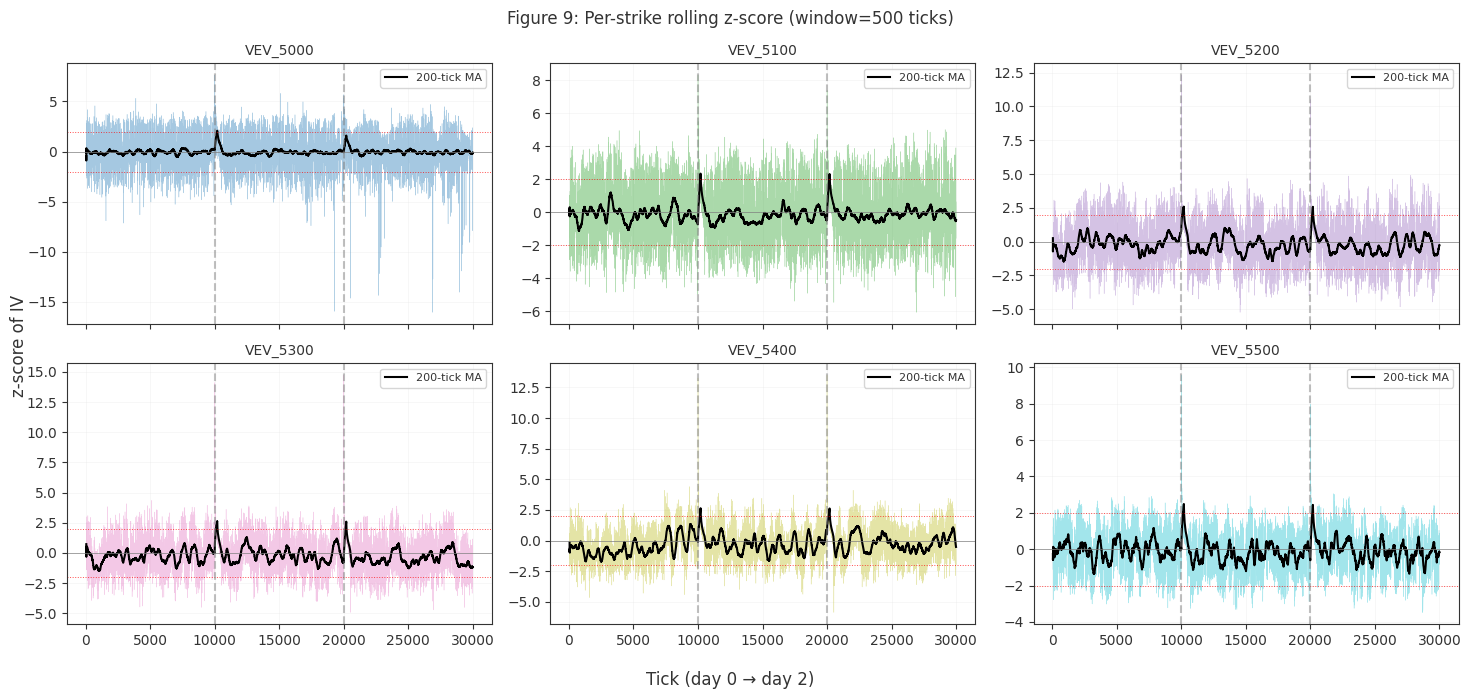

In [88]:
plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'axes.edgecolor': '#333', 'axes.labelcolor': '#333', 'axes.titlecolor': '#333',
    'xtick.color': '#333', 'ytick.color': '#333', 'text.color': '#333',
    'grid.color': '#ddd', 'legend.facecolor': 'white', 'legend.edgecolor': '#ccc',
})

fig, axes = plt.subplots(2, 3, figsize=(15, 7), sharex=True, facecolor='white')
palette = plt.cm.tab10(np.linspace(0, 1, len(USABLE)))

for ax, color, sym in zip(axes.flat, palette, USABLE):
    z_series = z_wide[sym].reset_index(drop=True)
    x = np.arange(len(z_series))
    ax.plot(x, z_series, linewidth=0.3, alpha=0.4, color=color)
    ax.plot(x, z_series.rolling(200, min_periods=1).mean(),
            linewidth=1.5, color='black', label='200-tick MA')
    ax.axhline(y=0, color='gray', linewidth=0.5)
    ax.axhline(y=2, color='red', linewidth=0.7, linestyle=':', alpha=0.7)
    ax.axhline(y=-2, color='red', linewidth=0.7, linestyle=':', alpha=0.7)
    for d in [1, 2]:
        ax.axvline(x=10000*d, color='gray', linestyle='--', alpha=0.5)
    ax.set_title(sym, fontsize=10)
    ax.legend(fontsize=8, loc='upper right')
    ax.grid(alpha=0.3)

fig.suptitle(f'Figure 9: Per-strike rolling z-score (window={WINDOW} ticks)', fontsize=12)
fig.supxlabel('Tick (day 0 → day 2)')
fig.supylabel('z-score of IV')
plt.tight_layout()
plt.show()